<a href="https://colab.research.google.com/github/aymuos/endgame/blob/main/08_simulator_bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook Objective :
======================
This notebook implements a modular contextual bandit simulator designed to optimize delivery ordering sequences. It evaluates how well reinforcement learning policies perform when restricted to causal features (identified via CD-NOD and PC algorithms) compared to standard full-feature models.

Architecture
------------
- RewardOracle  (ABC) ← pre-trained LightGBM per city, FROZEN, simulates the environment . It receives all available features (static and dynamic) to predict the incremental delivery duration, denoted as $\Delta t$. The bandit's reward is $-\Delta t$ which makes it a reward-maximization problem.


- PolicyModel   (ABC)  ←  An online regression model updated continuously inside the bandit. Crucially, it only observes causal features (shared invariant parents and city-specific augmentations) to score available deliveries, enforcing policy transferability. We have two implementations: Streaming SGD (OnlineSGDPolicyModel) and incremental Ridge regression (RidgePolicyModel)


- BanditBase    (ABC)  ← selection policy wrapping a PolicyModel

    Bandit Policies: The selection algorithms wrapping the PolicyModel.  SquareCB: A nonparametric contextual bandit reduction to regression that relies on inverse squared gaps for arm selection.  Thompson Sampling: A Bayesian approach utilizing the Ridge model's parameters to sample from a Gaussian posterior.  Baselines: Includes Greedy Nearest-Neighbor (minimizing immediate Euclidean distance), Random selection, and an Oracle-Greedy ceiling.

- BatchEnvironment     ← state management + dynamic feature recomputation each step . Manages the courier's physical state during a delivery batch. It calculates planar Euclidean distances (accounting for the LaDe dataset's affine-transformed coordinate space) and recomputes dynamic features like dist_from_current and elapsed_route_time at every step, ensuring no future information leaks from the historical logs.


- Simulator            ← runs one batch as one episode, collects metrics

Key design invariants
---------------------
- RewardOracle uses ALL features (static + dynamic). Goal: predictive accuracy.
- PolicyModel uses CAUSAL features only (φ_shared + φ_c per city). Goal: transferable policy.
- RewardOracle is never retrained during simulation. It is a frozen environment surrogate.
- PolicyModel is updated online after every delivery selection.
- Reward = −Δt  (bandit maximises, here we minimise duration).
- All distances are Euclidean (LaDe coordinates are affine-transformed planar, not real lat/lng).
- Dynamic features are recomputed from simulator state at every step, never read from the log.

Swapping components
-------------------
  Replace reward oracle:  subclass OracleBase, pass to BatchEnvironment.
  Replace policy model:   subclass PolicyModelBase, pass to SquareCBBandit / ThompsonSamplingBandit.
  Replace bandit:         subclass BanditBase, pass to Simulator.run_episode().

In [1]:
local = True

if not local:
    from google.colab import drive
    drive.mount('/content/drive')

In [2]:


from __future__ import annotations

import math
import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy import stats
from sklearn.linear_model import SGDRegressor, Ridge
from sklearn.preprocessing import StandardScaler




# SECTION 1 — Causal feature config

**Feature-count reconciliation.** The policy causal set uses the 0.50 PC/Markov-blanket stability threshold from `02_PC_delivery_level.ipynb`, matching `07_reward_oracle.ipynb`. The 07 Causal-Dynamic counts (Shanghai 20, Hangzhou 17, Chongqing 18) include raw `current_hour` in addition to its cyclic transforms. Raw `current_hour` is not in the frozen 35-feature oracle schema, so it is deliberately excluded here to preserve a fair subset relation for Ablation A1. The resulting valid policy counts are Shanghai 19, Hangzhou 16, and Chongqing 17.


In [3]:
# Causal-policy configuration for Ablation A1.
#
# This reproduces the per-city PC/Markov-blanket selection used in
# 07_reward_oracle.ipynb at stability threshold 0.50.  The previous
# hand-curated PHI_SHARED + PC_EXTRA configuration was a smaller directed
# parent set, so it was not comparable to 07's Causal_Dynamic experiment.
CAUSAL_STABILITY_THRESHOLD = 0.50

CAUSAL_STATIC_FEATURES_BY_CITY: Dict[str, List[str]] = {
    "Shanghai": [
        "batch_size", "courier_eta_ewm", "hour_sin",
        "isolated_delivery", "pickup_destination_distance",
        "precipitation", "same_aoi_share_in_batch",
        "spatial_congestion_norm", "temperature_2m",
        "typecode_cb", "windspeed_10m",
    ],
    "Hangzhou": [
        "batch_size", "courier_eta_ewm", "hour_sin",
        "pickup_destination_distance", "precipitation",
        "spatial_congestion_norm", "temperature_2m", "windspeed_10m",
    ],
    "Chongqing": [
        "batch_size", "courier_eta_ewm", "hour_cos", "hour_sin",
        "idle_fraction", "pickup_destination_distance",
        "spatial_congestion_norm", "temperature_2m", "typecode_cb",
    ],
}

# Counterfactual state variables recomputed by BatchEnvironment at each decision.
# Raw current_hour is intentionally absent: the frozen 35-feature oracle uses
# hour_sin_dynamic/hour_cos_dynamic instead, so A1 must keep causal features
# a strict subset of the full oracle feature set.
DYNAMIC_POLICY_FEATURES: List[str] = [
    "dist_from_current", "remaining_orders", "batch_progress",
    "elapsed_route_time", "last_duration", "cumulative_distance",
    "hour_sin_dynamic", "hour_cos_dynamic",
]

def get_causal_features(city: str) -> List[str]:
    """0.50-stability causal static set plus valid simulator dynamics."""
    if city not in CAUSAL_STATIC_FEATURES_BY_CITY:
        raise ValueError(f"Unsupported city: {city}")
    return list(dict.fromkeys(
        CAUSAL_STATIC_FEATURES_BY_CITY[city] + DYNAMIC_POLICY_FEATURES
    ))

def get_policy_features(
    city: str, feature_set: str, oracle_feature_names: List[str]
) -> List[str]:
    """Return the policy inputs for A1; causal is a subset of full."""
    if feature_set == "causal":
        return get_causal_features(city)
    if feature_set == "full":
        return list(oracle_feature_names)
    raise ValueError("feature_set must be 'causal' or 'full'.")


# SECTION 2 — Data structures


In [4]:
@dataclass
class BatchState:
    """
    Mutable state of the simulator at the START of a delivery selection step.
    Represents everything the bandit can observe before choosing the next delivery.
    All values reflect the situation BEFORE step `step` is executed.
    """
    current_lat: float          # courier position after last completed delivery
    current_lng: float
    elapsed_route_time: float   # cumulative minutes elapsed in this batch
    cumulative_distance: float  # cumulative Euclidean distance travelled
    last_duration: float        # Δt of the most recently completed delivery (0 if first)
    step: int                   # 0-indexed step counter (= number of completed deliveries)
    batch_size: int             # total deliveries in this batch
    start_hour: float           # fractional hour at batch start (for current_hour computation)
    batch_id: str               # for logging

    @property
    def remaining_orders(self) -> int:
        return self.batch_size - self.step

    @property
    def batch_progress(self) -> float:
        return self.step / max(self.batch_size, 1)

    @property
    def current_hour(self) -> float:
        return self.start_hour + self.elapsed_route_time / 60.0

    @property
    def hour_sin_dynamic(self) -> float:
        return math.sin(self.current_hour * 2 * math.pi / 24)

    @property
    def hour_cos_dynamic(self) -> float:
        return math.cos(self.current_hour * 2 * math.pi / 24)


@dataclass
class DeliveryRecord:
    """
    One delivery within a batch.  static_features holds all pre-computed
    static values (structural + operational + environmental + temporal) exactly
    as they appear in FINAL_FEATURES from the oracle training script.
    poi_lat / poi_lng are stored separately because the environment uses them
    to compute dist_from_current at each step.
    """
    delivery_id: str
    poi_lat: float
    poi_lng: float
    static_features: Dict[str, float]   # key = feature name, value = scalar
    logged_rank: int = -1               # batch_rank_actual from log, for LoggedPolicy


@dataclass
class EpisodeResult:
    """Metrics collected from one batch episode under one policy."""
    city: str
    batch_id: str
    policy_name: str
    sequence: List[str]                  # ordered delivery_ids
    predicted_durations: List[float]     # oracle Δt per step
    total_duration: float                # Σ predicted_durations
    mean_duration: float
    step_regrets: List[float]            # one-step counterfactual oracle regret
    step_rewards: List[float]            # −Δt per step (what bandit maximised)


# SECTION 3 — Reward Oracle (environment surrogate — NOT the policy)


**Predictive step**: At each step of a delivery sequence, the simulator asks: "If the courier delivers order X next, how long will it take?" The LightGBM model predicts this incremental duration
(Δt).
**Reward**: The bandit policy receives a reward of −Δt
(since the goal is to minimize total delivery time, maximizing reward is equivalent to minimizing duration).

The objective is to minimize the total delivery time, which can be expressed as:

$$ \min_{\pi} \sum_{t} \Delta t_t $$

Where $\pi$ is the policy, and $\Delta t_t$ is the incremental duration for each delivery $t$.

In [5]:
class OracleBase(ABC):
    """
    Pre-trained model that predicts incremental duration Δt for a delivery
    given its full feature vector (static + dynamic, all features).
    This is the ENVIRONMENT surrogate.  Never updated during simulation.
    """
    @abstractmethod
    def predict(self, feature_vector: np.ndarray) -> float:
        """Single prediction.  feature_vector must match training feature order."""

    @abstractmethod
    def predict_batch(self, feature_matrix: np.ndarray) -> np.ndarray:
        """Vectorised prediction over multiple arms at once."""

    @abstractmethod
    def feature_names(self) -> List[str]:
        """Returns ordered feature names that this oracle expects."""


class LightGBMOracle(OracleBase):
    """
    Wraps a pre-trained LightGBM model saved via joblib.
    Drop-in replacement: swap model_path or swap entire class with XGBoostOracle, etc.
    """
    def __init__(self, model_path: str, feature_names_list: List[str]):
        self._model = joblib.load(model_path)
        self._feature_names = feature_names_list

    def predict(self, feature_vector: np.ndarray) -> float:
        return float(self._model.predict(feature_vector.reshape(1, -1))[0])

    def predict_batch(self, feature_matrix: np.ndarray) -> np.ndarray:
        return self._model.predict(feature_matrix)

    def feature_names(self) -> List[str]:
        return self._feature_names


# SECTION 4 — Policy Model (online learner inside the bandit)


In [6]:
class PolicyModelBase(ABC):
    """
    Online regression model used by the bandit to score arms.
    Receives CAUSAL features only. Gets updated after each delivery selection.
    """
    @abstractmethod
    def predict(self, features: np.ndarray) -> float:
        pass
    @abstractmethod
    def predict_batch(self, features: np.ndarray) -> np.ndarray:
        pass
    @abstractmethod
    def update(self, features: np.ndarray, reward: float) -> None:
        pass

class OnlineSGDPolicyModel(PolicyModelBase):
    """
    Online linear regression via SGD. Fast, streaming, no batch refit needed.
    """
    def __init__(self, n_features: int, learning_rate: float = 0.01,
                 alpha: float = 1e-4, random_state: int = 42):
        self._scaler = StandardScaler()
        self._scaler_fitted = False
        self._model = SGDRegressor(
            loss="squared_error", learning_rate="constant",
            eta0=learning_rate, alpha=alpha, random_state=random_state, warm_start=True
        )
        self._buffer_X, self._buffer_y = [], []
        self._min_samples_before_fit = max(10, n_features)

    def _ensure_fitted(self) -> bool:
        if len(self._buffer_y) < self._min_samples_before_fit: return False
        if not self._scaler_fitted:
            X = np.vstack(self._buffer_X)
            self._scaler.fit(X)
            self._scaler_fitted = True
            self._model.partial_fit(self._scaler.transform(X), np.array(self._buffer_y))
        return True

    def predict(self, features: np.ndarray) -> float:
        if not self._ensure_fitted(): return 0.0
        return float(self._model.predict(self._scaler.transform(features.reshape(1, -1)))[0])

    def predict_batch(self, features: np.ndarray) -> np.ndarray:
        if not self._ensure_fitted(): return np.zeros(len(features))
        return self._model.predict(self._scaler.transform(features))

    def update(self, features: np.ndarray, reward: float) -> None:
        if not self._scaler_fitted:
            self._buffer_X.append(features); self._buffer_y.append(reward)
            self._ensure_fitted(); return
        self._model.partial_fit(self._scaler.transform(features.reshape(1, -1)), np.array([reward]))

class RidgePolicyModel(PolicyModelBase):
    """
    Incremental Ridge regression using the Sherman-Morrison rank-1 update.
    Closed-form, no learning rate to tune.
    """
    def __init__(self, n_features: int, alpha: float = 1.0,
                 min_samples_before_fit: Optional[int] = None):
        self._alpha = float(alpha)
        self._theta = np.zeros(n_features)
        self._b = np.zeros(n_features)
        self._A_inv = (1.0 / alpha) * np.eye(n_features)
        # Fit once on observed contexts, then freeze the scale.  A changing
        # scale would make past Sherman-Morrison updates incompatible with
        # new observations.
        self._scaler = StandardScaler()
        self._scaler_fitted = False
        self._buffer_X, self._buffer_y = [], []
        self._min_samples_before_fit = min_samples_before_fit or max(10, n_features)

    def _update_inv(self, z: np.ndarray) -> None:
        # Sherman-Morrison: (A + z z^T)^{-1} = A^{-1} - (A^{-1} z z^T A^{-1}) / (1 + z^T A^{-1} z)
        Az = self._A_inv @ z
        self._A_inv -= np.outer(Az, Az) / (1.0 + z @ Az)

    @property
    def fitted(self) -> bool:
        return self._scaler_fitted

    def prefit_scaler(self, features: np.ndarray) -> None:
        """Fit the context scaler on held-out calibration contexts only."""
        X = np.asarray(features, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.ndim != 2 or len(X) == 0:
            raise ValueError("Ridge scaler calibration requires a non-empty 2-D array.")
        self._scaler.fit(X)
        self._scaler_fitted = True
        # Calibration determines only the fixed feature scale; it must not
        # leak rewards or initialize the policy parameters.
        self._buffer_X, self._buffer_y = [], []

    def transform_features(self, features: np.ndarray) -> np.ndarray:
        X = np.asarray(features, dtype=float)
        if not self._scaler_fitted:
            raise RuntimeError('Ridge scaler has not been fitted.')
        return self._scaler.transform(X.reshape(1, -1) if X.ndim == 1 else X)

    def _update_scaled(self, z: np.ndarray, reward: float) -> None:
        self._update_inv(z)
        self._b += reward * z
        self._theta = self._A_inv @ self._b

    def _ensure_fitted(self) -> bool:
        if self._scaler_fitted:
            return True
        if len(self._buffer_y) < self._min_samples_before_fit:
            return False
        X = np.vstack(self._buffer_X)
        self._scaler.fit(X)
        self._scaler_fitted = True
        for z, reward in zip(self._scaler.transform(X), self._buffer_y):
            self._update_scaled(z, reward)
        self._buffer_X, self._buffer_y = [], []
        return True

    def predict(self, features: np.ndarray) -> float:
        if not self._scaler_fitted: return 0.0
        return float(self.transform_features(features).ravel() @ self._theta)

    def predict_batch(self, features: np.ndarray) -> np.ndarray:
        if not self._scaler_fitted: return np.zeros(len(features))
        return self.transform_features(features) @ self._theta

    def update(self, features: np.ndarray, reward: float) -> None:
        if not self._scaler_fitted:
            self._buffer_X.append(np.asarray(features, dtype=float).copy())
            self._buffer_y.append(float(reward))
            self._ensure_fitted()
            return
        self._update_scaled(self.transform_features(features).ravel(), reward)

class RandomFourierFeatureMap:
    """
    Random Fourier Features approximating an RBF kernel (Rahimi & Recht, 2007).
    phi(z) = sqrt(2/D) * cos(W z / lengthscale + b), W ~ N(0,I), b ~ U(0, 2*pi).
    Requires standardized input — fit() computes the scaler AND samples W, b once.
    """
    def __init__(self, n_features: int, n_components: int = 256,
                 lengthscale: Optional[float] = None, random_state: int = 42):
        self._d, self._D = n_features, n_components
        self._lengthscale = lengthscale
        self._rng = np.random.default_rng(random_state)
        self._scaler = StandardScaler()
        self._fitted = False

    def fit(self, X_sample: np.ndarray) -> None:
        """Call once on a representative batch of arm features to set bandwidth and W/b."""
        self._scaler.fit(X_sample)
        Xs = self._scaler.transform(X_sample)
        if self._lengthscale is None:
            # median heuristic: median pairwise distance in standardized space
            from scipy.spatial.distance import pdist
            self._lengthscale = float(np.median(pdist(Xs))) or 1.0
        self._W = self._rng.normal(size=(self._D, self._d)) / self._lengthscale
        self._b = self._rng.uniform(0, 2 * np.pi, size=self._D)
        self._fitted = True

    def transform(self, X: np.ndarray) -> np.ndarray:
        if not self._fitted: raise RuntimeError("Fit map first.")
        Xs = self._scaler.transform(X.reshape(1, -1) if X.ndim == 1 else X)
        proj = Xs @ self._W.T + self._b
        return np.sqrt(2.0 / self._D) * np.cos(proj)

class RFFPolicyModel(PolicyModelBase):
    """
    Kernelized policy model: RandomFourierFeatureMap + the same RidgePolicyModel
    machinery applied in transformed feature space phi(z).
    """
    def __init__(self, feature_map: RandomFourierFeatureMap, alpha: float = 1.0):
        self._map = feature_map
        self._ridge = RidgePolicyModel(feature_map._D, alpha=alpha)
    def prefit_scaler(self, features: np.ndarray) -> None:
        self._ridge.prefit_scaler(self._map.transform(features))
    def transform_features(self, f: np.ndarray) -> np.ndarray:
        # Original inputs are standardized in the RFF map; Ridge then uses
        # its fixed phi-space calibration for a well-conditioned posterior.
        return self._ridge.transform_features(self._map.transform(f))
    def predict(self, f: np.ndarray) -> float: return self._ridge.predict(self._map.transform(f).ravel())
    def predict_batch(self, f: np.ndarray) -> np.ndarray: return self._ridge.predict_batch(self._map.transform(f))
    def update(self, f: np.ndarray, r: float) -> None: self._ridge.update(self._map.transform(f).ravel(), r)

# SECTION 5 — Bandit policies


In [7]:
class BanditBase(ABC):
    """Abstract bandit.  arm_features: (n_arms, n_causal_features)."""
    @abstractmethod
    def select_arm(self, arm_features: np.ndarray) -> int:
        """Return index into arm_features of the chosen arm."""

    @abstractmethod
    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        """Update policy with observed reward."""

    @property
    def name(self) -> str:
        return self.__class__.__name__

class SquareCBBandit(BanditBase):
    """
    SquareCB (Foster & Rakhlin, 2020) — contextual bandit reduction to regression.
    """
    def __init__(self, policy_model: PolicyModelBase, gamma: float = 1.0,
                 random_state: int = 42):
        self._model = policy_model
        self._gamma = gamma
        self._rng = np.random.default_rng(random_state)
        self._n_selections = 0
    @property
    def name(self) -> str:
        return f"SquareCB(γ={self._gamma})"
    @property
    def name(self) -> str:
        alpha = getattr(self._model, "_alpha", None)
        alpha_text = f", alpha={alpha:g}" if alpha is not None else ""
        return f"SquareCB(gamma={self._gamma}{alpha_text})"
    def select_arm(self, arm_features: np.ndarray) -> int:
        if self._gamma <= 0: raise ValueError("gamma must be positive.")
        r_hat = self._model.predict_batch(arm_features)
        gaps = r_hat.max() - r_hat
        lower, upper = 1.0, float(len(r_hat))
        for _ in range(60):
            lam = (lower + upper) / 2.0
            if np.sum(1.0 / (lam + 2.0 * self._gamma * gaps)) > 1.0:
                lower = lam
            else:
                upper = lam
        probs = 1.0 / (upper + 2.0 * self._gamma * gaps)
        probs /= probs.sum()
        return int(self._rng.choice(len(r_hat), p=probs))
    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        self._model.update(chosen_arm_features, reward)
        self._n_selections += 1

class ThompsonSamplingBandit(BanditBase):
    """
    Thompson Sampling. Supports linear (RidgePolicyModel) or kernelized (RFFPolicyModel).
    Samples theta ~ N(mu, v^2 * A_inv) to handle exploration.
    """
    def __init__(self, n_features: int, v_sq: float = 0.25,
                 sigma_sq: float = 1.0, random_state: int = 42,
                 alpha: Optional[float] = None,
                 policy_model: Optional[PolicyModelBase] = None):
        self._v_sq = v_sq
        self._alpha = float(alpha) if alpha is not None else 1.0 / sigma_sq
        self._sigma_sq = sigma_sq
        self._rng = np.random.default_rng(random_state)
        if policy_model is not None:
            self._model = policy_model
        else:
            self._model = RidgePolicyModel(n_features, alpha=self._alpha)
    @property
    def name(self) -> str:
        base_name = "KernelTS" if hasattr(self._model, '_map') else "ThompsonSampling"
        return f"{base_name}(v²={self._v_sq})"
    @property
    def name(self) -> str:
        base_name = "KernelTS" if hasattr(self._model, '_map') else "ThompsonSampling"
        target = self._model._ridge if hasattr(self._model, '_ridge') else self._model
        alpha = getattr(target, "_alpha", None)
        alpha_text = f", alpha={alpha:g}" if alpha is not None else ""
        return f"{base_name}(v_sq={self._v_sq}{alpha_text})"
    def select_arm(self, arm_features: np.ndarray) -> int:
        # Access the underlying ridge parameters for posterior sampling
        target = self._model._ridge if hasattr(self._model, '_ridge') else self._model
        theta_sample = self._rng.multivariate_normal(mean=target._theta, cov=self._v_sq * target._A_inv)
        if not target.fitted:
            # Avoid a deterministic first-arm bias during Ridge calibration.
            return int(self._rng.integers(len(arm_features)))
        if hasattr(self._model, '_map'):
            scores = self._model.transform_features(arm_features) @ theta_sample
        else:
            scores = target.transform_features(arm_features) @ theta_sample
        return int(np.argmax(scores))
    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        self._model.update(chosen_arm_features, reward)

# SECTION 6 — Baseline policies (no learning)


In [8]:
class RandomBandit(BanditBase):
    """Uniform random arm selection.  Floor baseline."""
    def __init__(self, random_state: int = 42):
        self._rng = np.random.default_rng(random_state)

    @property
    def name(self) -> str:
        return "Random"

    def select_arm(self, arm_features: np.ndarray) -> int:
        return int(self._rng.integers(0, len(arm_features)))

    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        pass


class GreedyNNBandit(BanditBase):
    """
    Greedy nearest-neighbour: always pick the delivery closest to current position.
    dist_from_current must be the FIRST feature in arm_features (index 0).
    Ensure CDNOD_FEATURES[0] == 'dist_from_current' or adjust dist_idx below.
    """
    def __init__(self, dist_feature_idx: int = 0):
        self._dist_idx = dist_feature_idx

    @property
    def name(self) -> str:
        return "GreedyNN"

    def select_arm(self, arm_features: np.ndarray) -> int:
        # arm_features[:, dist_idx] = dist_from_current for each arm
        # Maximise reward = −duration ≈ minimise distance → argmin distance
        # But reward is negative duration, so we want argmin(dist_from_current)
        return int(np.argmin(arm_features[:, self._dist_idx]))

    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        pass


class MyopicOracleBandit(BanditBase):
    """
    At each step, calls the reward oracle for ALL remaining arms and picks the
    one with the lowest immediate predicted duration.  This is a myopic
    benchmark, not a globally optimal route oracle.  Used to compute NPG.
    Requires access to the environment — injected at construction.
    """
    def __init__(self):
        # _scores is set by BatchEnvironment.compute_all_oracle_scores()
        # before select_arm is called each step.
        self._scores: Optional[np.ndarray] = None

    @property
    def name(self) -> str:
        return "MyopicOracle"

    def set_oracle_scores(self, scores: np.ndarray) -> None:
        """Called by the simulator just before select_arm at each step."""
        self._scores = scores

    def select_arm(self, arm_features: np.ndarray) -> int:
        if self._scores is None:
            return 0
        return int(np.argmax(self._scores))  # scores = −duration, argmax = min duration

    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        pass


class LoggedOrderBandit(BanditBase):
    """
    Replays the actual logged courier ordering (batch_rank_actual).
    Used to score the human-expert baseline through the same oracle.
    """
    @property
    def name(self) -> str:
        return "LoggedOrder"

    def select_arm(self, arm_features: np.ndarray) -> int:
        # Selection is overridden by Simulator using delivery.logged_rank.
        # This method is only a fallback.
        return 0

    def update(self, chosen_arm_features: np.ndarray, reward: float) -> None:
        pass


# SECTION 7 — BatchEnvironment


In a real delivery run, the features of remaining packages change as the courier moves. The BatchEnvironment class manages this simulator state:

When a delivery is completed, the courier's location is updated to that customer's coordinates.
The elapsed time, current hour, and cumulative distance are advanced.
For the next step, dynamic features (e.g., dist_from_current, remaining_orders, batch_progress, elapsed_route_time, cumulative_distance) are recomputed from the simulator state for all remaining candidate deliveries.

In [9]:
class BatchEnvironment:
    """
    Manages simulator state and feature computation for one batch episode.

    Responsibilities:
      - Initialise state at batch start.
      - For each step: compute dynamic features for ALL remaining deliveries.
      - Assemble two feature vectors per delivery:
          oracle_vec  → ALL features in oracle training order (for reward oracle)
          policy_vec  → CAUSAL features only (for bandit policy model)
      - Execute a delivery selection, update state, return reward.

    Dynamic feature computation is fully self-contained here: no logged values
    are carried over.  This ensures train/inference consistency.
    """

    def __init__(
        self,
        oracle: OracleBase,
        oracle_feature_names: List[str],    # FINAL_FEATURES from training script
        causal_feature_names: List[str],    # get_causal_features(city)
    ):
        self._oracle = oracle
        self._oracle_feats = oracle_feature_names
        self._causal_feats = causal_feature_names

    # ------------------------------------------------------------------
    # Episode initialisation
    # ------------------------------------------------------------------

    def reset(
        self,
        deliveries: List[DeliveryRecord],
        start_lat: float,
        start_lng: float,
        start_hour: float,
        batch_id: str,
    ) -> Tuple[BatchState, List[DeliveryRecord]]:
        """
        Returns initial state and a mutable copy of the delivery list.
        start_lat/lng = courier position at batch dispatch (use mean receipt coords
        or dedicated pickup coords if available).
        """
        state = BatchState(
            current_lat=start_lat,
            current_lng=start_lng,
            elapsed_route_time=0.0,
            cumulative_distance=0.0,
            last_duration=0.0,
            step=0,
            batch_size=len(deliveries),
            start_hour=start_hour,
            batch_id=batch_id,
        )
        return state, list(deliveries)

    # ------------------------------------------------------------------
    # Dynamic feature computation
    # ------------------------------------------------------------------

    @staticmethod
    def euclidean(lat1: float, lng1: float, lat2: float, lng2: float) -> float:
        """
        Planar Euclidean distance in coordinate units.
        Correct for LaDe's affine-transformed space (NOT haversine).
        """
        return math.sqrt((lat2 - lat1) ** 2 + (lng2 - lng1) ** 2)

    def _dynamic_features(
        self,
        delivery: DeliveryRecord,
        state: BatchState,
    ) -> Dict[str, float]:
        """
        Compute all dynamic (position-dependent) features for one candidate delivery
        given the current simulator state.  These are the features that must NOT be
        read from the log — they depend on which ordering the bandit has proposed.
        """
        dist = self.euclidean(
            state.current_lat, state.current_lng,
            delivery.poi_lat, delivery.poi_lng,
        )
        return {
            "dist_from_current":    dist,
            "remaining_orders":     float(state.remaining_orders),
            "batch_progress":       state.batch_progress,
            "elapsed_route_time":   state.elapsed_route_time,
            "last_duration":        state.last_duration,
            "current_hour":         state.current_hour,
            "cumulative_distance":  state.cumulative_distance,
            # cyclic encoding of the updated hour (matches training feature names)
            "hour_sin_dynamic":     state.hour_sin_dynamic,
            "hour_cos_dynamic":     state.hour_cos_dynamic,
        }

    def _assemble_oracle_vector(
        self,
        delivery: DeliveryRecord,
        dynamic: Dict[str, float],
    ) -> np.ndarray:
        """
        Assemble feature vector for the reward oracle in exactly the order
        oracle_feature_names specifies.  Missing static features raise KeyError
        early, not silently during prediction.
        """
        merged = {**delivery.static_features, **dynamic}
        return np.array([merged[f] for f in self._oracle_feats], dtype=np.float32)

    def _assemble_policy_vector(
        self,
        delivery: DeliveryRecord,
        dynamic: Dict[str, float],
    ) -> np.ndarray:
        """
        Assemble feature vector for the bandit policy model.
        Uses CAUSAL features only — causal_feature_names defines the order.
        """
        merged = {**delivery.static_features, **dynamic}
        return np.array([merged[f] for f in self._causal_feats], dtype=np.float32)

    # ------------------------------------------------------------------
    # Per-step interface
    # ------------------------------------------------------------------

    def get_arm_vectors(
        self,
        remaining: List[DeliveryRecord],
        state: BatchState,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        For all remaining deliveries, compute:
          oracle_matrix : (n_arms, n_oracle_features)   — for reward oracle
          policy_matrix : (n_arms, n_causal_features)   — for bandit policy
        """
        oracle_rows, policy_rows = [], []
        for d in remaining:
            dyn = self._dynamic_features(d, state)
            oracle_rows.append(self._assemble_oracle_vector(d, dyn))
            policy_rows.append(self._assemble_policy_vector(d, dyn))
        return np.vstack(oracle_rows), np.vstack(policy_rows)

    def score_all_arms_oracle(
        self,
        oracle_matrix: np.ndarray,
    ) -> np.ndarray:
        """
        Call reward oracle for all arms at once.
        Returns scores = −predicted_duration (so argmax → min duration).
        Used by MyopicOracleBandit and for metric computation.
        """
        durations = self._oracle.predict_batch(oracle_matrix)
        return -durations   # reward = −Δt

    def step(
        self,
        state: BatchState,
        chosen: DeliveryRecord,
        chosen_oracle_vec: np.ndarray,
    ) -> Tuple[BatchState, float]:
        """
        Execute selecting `chosen` as the next delivery.
        Returns updated state and the reward (= −predicted_duration).
        """
        predicted_duration = self._oracle.predict(chosen_oracle_vec)
        reward = -predicted_duration

        dist_hop = self.euclidean(
            state.current_lat, state.current_lng,
            chosen.poi_lat, chosen.poi_lng,
        )

        new_state = BatchState(
            current_lat=chosen.poi_lat,
            current_lng=chosen.poi_lng,
            elapsed_route_time=state.elapsed_route_time + predicted_duration,
            cumulative_distance=state.cumulative_distance + dist_hop,
            last_duration=predicted_duration,
            step=state.step + 1,
            batch_size=state.batch_size,
            start_hour=state.start_hour,
            batch_id=state.batch_id,
        )
        return new_state, reward


# SECTION 8 — Simulator


In [10]:
class Simulator:
    """
    Runs one batch as one episode.
    For every remaining delivery at each step:
      1. Compute oracle + policy feature vectors.
      2. (If MyopicOracleBandit) inject current-state oracle scores.
      3. Bandit selects an arm.
      4. Environment executes the selection → (new_state, reward).
      5. Bandit updates its policy model.
    """

    def __init__(self, env: BatchEnvironment):
        self._env = env

    def run_episode(
        self,
        deliveries: List[DeliveryRecord],
        bandit: BanditBase,
        city: str,
        start_lat: float,
        start_lng: float,
        start_hour: float,
        batch_id: str = "",
    ) -> EpisodeResult:
        state, remaining = self._env.reset(
            deliveries, start_lat, start_lng, start_hour, batch_id
        )

        sequence: List[str] = []
        predicted_durations: List[float] = []
        step_rewards: List[float] = []
        step_regrets: List[float] = []

        while remaining:
            oracle_mat, policy_mat = self._env.get_arm_vectors(remaining, state)

            # Evaluate all potential actions at the policy's current state.
            # These are the counterfactual outcomes needed for valid regret.
            oracle_scores = self._env.score_all_arms_oracle(oracle_mat)

            # Special handling for LoggedOrderBandit: follow actual rank
            if isinstance(bandit, LoggedOrderBandit):
                arm_idx = self._logged_order_index(remaining)
            elif isinstance(bandit, MyopicOracleBandit):
                bandit.set_oracle_scores(oracle_scores)
                arm_idx = bandit.select_arm(policy_mat)
            else:
                arm_idx = bandit.select_arm(policy_mat)

            chosen = remaining[arm_idx]
            state, reward = self._env.step(state, chosen, oracle_mat[arm_idx])

            bandit.update(policy_mat[arm_idx], reward)

            sequence.append(chosen.delivery_id)
            predicted_durations.append(-reward)   # convert back to positive duration
            step_rewards.append(reward)
            step_regrets.append(float(oracle_scores.max() - oracle_scores[arm_idx]))
            remaining.pop(arm_idx)

        total = sum(predicted_durations)
        return EpisodeResult(
            city=city,
            batch_id=batch_id,
            policy_name=bandit.name,
            sequence=sequence,
            predicted_durations=predicted_durations,
            total_duration=total,
            mean_duration=total / max(len(predicted_durations), 1),
            step_regrets=step_regrets,
            step_rewards=step_rewards,
        )

    @staticmethod
    def _logged_order_index(remaining: List[DeliveryRecord]) -> int:
        """Return index of the delivery with the lowest logged_rank."""
        return int(min(range(len(remaining)), key=lambda i: remaining[i].logged_rank))


# SECTION 9 — Metrics


In [11]:
def compute_episode_metrics(
    bandit_results: List[EpisodeResult],
    baseline_results: Dict[str, List[EpisodeResult]],
) -> pd.DataFrame:
    """
    Given a list of bandit episode results and a dict of baseline results
    (keyed by policy name), compute per-city aggregate metrics.

    Returns a DataFrame with the thesis-facing metrics:
      city, policy, mean_total_batch_delta_t,
      delta_t_reduction_pct_vs_logged, delta_t_reduction_pct_vs_random,
      NPG (0=MyopicOracle; 1=Random), n_batches.
    """
    # The experiment runner also supplies learned-policy episodes in
    # baseline_results.  De-duplicate on the episode identity so each
    # policy/batch contributes exactly once to the aggregate.
    unique_results = {
        (r.city, r.policy_name, r.batch_id): r
        for r in [*bandit_results, *(
            episode for results in baseline_results.values() for episode in results
        )]
    }
    all_results = list(unique_results.values())

    df = pd.DataFrame([
        {
            "city": r.city,
            "policy": r.policy_name,
            "batch_id": r.batch_id,
            "total_duration": r.total_duration,
        }
        for r in all_results
    ])
    paired_stats = compute_paired_policy_statistics(df)

    agg = (
        df.groupby(["city", "policy"]).agg(
            mean_total_batch_delta_t=("total_duration", "mean"),
            std_total_batch_delta_t=("total_duration", "std"),
            n_batches=("batch_id", "nunique"),
        ).reset_index()
    )

    rows = []
    for city in agg["city"].unique():
        city_rows = agg[agg["city"] == city].set_index("policy")
        city_agg = city_rows["mean_total_batch_delta_t"]
        city_paired = paired_stats[paired_stats["city"] == city].set_index("policy")
        random_eta = city_agg.get("Random", np.nan)
        oracle_eta = city_agg.get("MyopicOracle", np.nan)
        logged_eta = city_agg.get("LoggedOrder", np.nan)

        for policy, mean_eta in city_agg.items():
            n_batches = int(city_rows.loc[policy, "n_batches"])
            std_eta = float(city_rows.loc[policy, "std_total_batch_delta_t"])
            ci_half_width = (
                stats.t.ppf(0.975, n_batches - 1) * std_eta / math.sqrt(n_batches)
                if n_batches > 1 and not np.isnan(std_eta) else np.nan
            )
            paired_row = city_paired.loc[policy]
            delta_logged = (
                (logged_eta - mean_eta) / logged_eta * 100
                if not np.isnan(logged_eta) and logged_eta != 0 else np.nan
            )
            delta_random = (
                (random_eta - mean_eta) / random_eta * 100
                if not np.isnan(random_eta) and random_eta != 0 else np.nan
            )
            npg = (
                (mean_eta - oracle_eta) / (random_eta - oracle_eta)
                if not np.isnan(oracle_eta) and not np.isnan(random_eta)
                   and random_eta != oracle_eta else np.nan
            )
            rows.append({
                "city": city, "policy": policy,
                "mean_total_batch_delta_t": round(mean_eta, 3),
                "std_total_batch_delta_t": round(std_eta, 3),
                "ci95_total_batch_delta_t": (
                    f"[{mean_eta - ci_half_width:.3f}, {mean_eta + ci_half_width:.3f}]"
                    if not np.isnan(ci_half_width) else "n/a"
                ),
                "delta_t_reduction_pct_vs_logged": round(delta_logged, 2),
                "delta_t_reduction_pct_vs_random": round(delta_random, 2),
                "mean_paired_delta_t_vs_logged": round(paired_row["mean_paired_delta_t_vs_logged"], 3),
                "paired_t_p_value_vs_logged": round(paired_row["paired_t_p_value_vs_logged"], 5),
                "paired_t_significant_0_05": bool(paired_row["paired_t_significant_0_05"]),
                "NPG": round(npg, 4) if not np.isnan(npg) else np.nan,
                "n_batches": n_batches,
            })

    return pd.DataFrame(rows).sort_values(["city", "mean_total_batch_delta_t"])


def compute_paired_policy_statistics(
    batch_results: pd.DataFrame,
    reference_policy: str = "LoggedOrder",
) -> pd.DataFrame:
    """Paired two-sided t-tests of each policy's batch duration vs logged order.

    Negative paired deltas favour the policy.  Pairing by batch_id controls for
    route difficulty, which an unpaired comparison would confound.
    """
    reference = batch_results[batch_results["policy"] == reference_policy][
        ["city", "batch_id", "total_duration"]
    ].rename(columns={"total_duration": "logged_total_duration"})
    rows = []
    for (city, policy), group in batch_results.groupby(["city", "policy"]):
        paired = group[["batch_id", "total_duration"]].merge(
            reference[reference["city"] == city][["batch_id", "logged_total_duration"]],
            on="batch_id", how="inner", validate="one_to_one",
        )
        differences = paired["total_duration"] - paired["logged_total_duration"]
        if policy == reference_policy or len(differences) < 2 or differences.std(ddof=1) == 0:
            p_value = np.nan
        else:
            p_value = float(stats.ttest_rel(
                paired["total_duration"], paired["logged_total_duration"]
            ).pvalue)
        rows.append({
            "city": city, "policy": policy,
            "n_paired_batches": len(paired),
            "mean_paired_delta_t_vs_logged": float(differences.mean()),
            "paired_t_p_value_vs_logged": p_value,
            "paired_t_significant_0_05": bool(not np.isnan(p_value) and p_value < 0.05),
        })
    return pd.DataFrame(rows)


def build_batch_results_frame(episode_results: Dict[str, List[EpisodeResult]]) -> pd.DataFrame:
    """Return one total predicted duration per policy, city, and batch."""
    return pd.DataFrame([
        {
            "city": result.city, "policy": result.policy_name,
            "batch_id": result.batch_id, "total_duration": result.total_duration,
        }
        for policy_results in episode_results.values() for result in policy_results
    ])


def plot_policy_duration_distributions(batch_results: pd.DataFrame, city: str) -> None:
    """Plot batch-level total predicted-duration distributions for one city."""
    city_results = batch_results[batch_results["city"] == city].copy()
    order = city_results.groupby("policy")["total_duration"].median().sort_values().index
    plt.figure(figsize=(14, 7))
    ax = sns.violinplot(
        data=city_results,
        x="policy",
        y="total_duration",
        order=order,
        inner=None,
        scale="width",
        cut=0,
        palette="pastel",
    )
    sns.boxplot(
        data=city_results,
        x="policy",
        y="total_duration",
        order=order,
        showcaps=True,
        boxprops={"facecolor": "white", "zorder": 2},
        whiskerprops={"linewidth": 1.0},
        showfliers=False,
        width=0.2,
        ax=ax,
    )
    sns.stripplot(
        data=city_results,
        x="policy",
        y="total_duration",
        order=order,
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.2,
        ax=ax,
    )

    medians = city_results.groupby("policy")["total_duration"].median()
    for tick, policy in enumerate(order):
        median = medians.loc[policy]
        ax.text(tick, median, f"{median:.1f}", ha="center", va="bottom", fontsize=8, color="black")

    logged_mean = city_results[city_results["policy"] == "LoggedOrder"]["total_duration"].mean()
    if not np.isnan(logged_mean):
        ax.axhline(logged_mean, color="#d62728", linestyle="--", linewidth=1.25,
                   label=f"LoggedOrder mean = {logged_mean:.2f}")
        ax.legend(loc="upper right", frameon=True)

    ax.set_title(f"{city}: distribution of total predicted batch Δt by policy")
    ax.set_xlabel("Policy")
    ax.set_ylabel("Total predicted batch Δt")
    ax.set_xticklabels(order, rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


def compute_cumulative_regret(
    bandit_results: List[EpisodeResult],
    _oracle_results: List[EpisodeResult],
) -> pd.DataFrame:
    """
    Computes cumulative one-step counterfactual regret per batch.

    Every available arm is scored by the frozen oracle at the policy's actual
    state.  Regret is the selected arm's gap to the best available arm, so it
    is non-negative.  It is a decision-level, not global-route, regret.
    """
    # Regret is measured against every available arm at the same state, not
    # against a separate greedy trajectory.  This guarantees non-negativity.
    rows = []
    cum_regret = 0.0
    for i, r in enumerate(bandit_results):
        regret = float(sum(r.step_regrets))
        cum_regret += regret
        rows.append({
            "batch_index": i,
            "city": r.city,
            "batch_id": r.batch_id,
            "instant_regret": regret,
            "cumulative_regret": cum_regret,
        })
    return pd.DataFrame(rows)


# SECTION 10 — Data loading helpers


In [12]:
def load_batches_from_parquet(
    path: str,
    oracle_feature_names: List[str],
    city: str,
    max_batches: Optional[int] = None,
    random_state: int = 42,
) -> List[Tuple[str, List[DeliveryRecord], float, float, float]]:
    """
    Load evaluation batches from a processed parquet file (output of 07_reward_oracle.py).
    Returns list of (batch_id, [DeliveryRecord...], start_lat, start_lng, start_hour).

    Expects columns: batch_id, batch_rank_actual, poi_lat, poi_lng,
    receipt_time (or start_hour pre-computed), + all FINAL_FEATURES.
    """
    df = pl.read_parquet(path)

    # A capped evaluation must not take the lexicographically first batches: that
    # can distort the city-level batch-size and route-complexity distribution.
    batch_ids = df.get_column("batch_id").unique().sort().to_list()
    if max_batches is not None and len(batch_ids) > max_batches:
        rng = np.random.default_rng(random_state)
        sampled_ids = rng.choice(batch_ids, size=max_batches, replace=False).tolist()
        df = df.filter(pl.col("batch_id").is_in(sampled_ids))

    # Static features = oracle features minus dynamic features
    dynamic_names = {
        "dist_from_current", "remaining_orders", "batch_progress",
        "elapsed_route_time", "last_duration", "current_hour",
        "cumulative_distance", "hour_sin_dynamic", "hour_cos_dynamic",
    }
    static_names = [f for f in oracle_feature_names if f not in dynamic_names]

    batches = []
    for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):
        group_sorted = group.sort("batch_rank_actual")
        rows = group_sorted.to_dicts()

        deliveries = []
        for row in rows:
            static_feats = {k: float(row.get(k, 0.0) or 0.0) for k in static_names}
            deliveries.append(DeliveryRecord(
                delivery_id=str(row.get("order_id", row.get("delivery_id", ""))),
                poi_lat=float(row["poi_lat"]),
                poi_lng=float(row["poi_lng"]),
                static_features=static_feats,
                logged_rank=int(row["batch_rank_actual"]),
            ))

        # Batch start: use first row's receipt_time-derived hour
        first = rows[0]
        if "start_hour" in first:
            start_hour = float(first["start_hour"])
        elif "receipt_time" in first:
            ts = pd.to_datetime(first["receipt_time"])
            start_hour = ts.hour + ts.minute / 60.0
        else:
            start_hour = 9.0   # fallback

        # Courier start position: use first delivery's logged previous position
        # approximation: mean POI position as centroid proxy for batch start
        mean_lat = float(np.mean([d.poi_lat for d in deliveries]))
        mean_lng = float(np.mean([d.poi_lng for d in deliveries]))

        batches.append((str(batch_id), deliveries, mean_lat, mean_lng, start_hour))
        if max_batches and len(batches) >= max_batches:
            break

    return batches


# SECTION 11 — Experiment runner


In [13]:
def run_city_experiment(
    city: str, oracle_model_path: str, data_path: str, oracle_feature_names: List[str],
    gamma_values: List[float] = (0.5, 1.0, 5.0), v_sq_values: List[float] = (0.1, 0.25, 1.0),
    alpha_values: List[float] = (0.1, 1.0, 10.0),
    max_eval_batches: Optional[int] = None, random_state: int = 42, feature_set: str = "causal",
    n_rff_components: int = 256, rff_fit_batches: int = 20, rff_fit_steps_per_batch: int = 3,
    plot_distributions: bool = False
) -> Dict[str, object]:
    policy_features = get_policy_features(city, feature_set, oracle_feature_names)
    n_feats = len(policy_features)
    oracle = LightGBMOracle(oracle_model_path, oracle_feature_names)
    env = BatchEnvironment(oracle, oracle_feature_names, policy_features)
    sim = Simulator(env)
    batches = load_batches_from_parquet(data_path, oracle_feature_names, city, max_eval_batches, random_state)

    # --- Fit the RFF map on a REPRESENTATIVE sample of arm vectors ---
    # Drawn with a DIFFERENT random_state offset than the evaluation draw above,
    # so calibration batches are (with high probability, though not guaranteed)
    # disjoint from the evaluation set -- load_batches_from_parquet doesn't
    # support explicit exclusion, so this is a practical mitigation, not a
    # strict guarantee; note this as a limitation if it matters for the thesis.
    #
    # Critically: we advance the environment state a few random steps within
    # each calibration batch before collecting arm vectors. A single batch at
    # its initial (step=0) state is degenerate for this purpose -- nearly all
    # causal STATIC features (batch_size, courier_eta_ewm, WSI, weather,
    # typecode, ...) are constant *within* one batch (they only vary *across*
    # batches), and dynamic features (remaining_orders, elapsed_route_time,
    # batch_progress, last_duration, cumulative_distance) are frozen at their
    # step-0 values unless the state is actually advanced. Fitting the
    # median-heuristic lengthscale on such a sample means only dist_from_current
    # varies at all, producing a near-meaningless bandwidth.
    calib_batches = load_batches_from_parquet(
        data_path, oracle_feature_names, city,
        max_batches=rff_fit_batches, random_state=random_state + 999,
    )
    fit_rng = np.random.default_rng(random_state)
    fit_arm_vectors = []
    for b_id, dls, slat, slng, shour in calib_batches:
        state, remaining = env.reset(dls, slat, slng, shour, b_id)
        n_steps = min(rff_fit_steps_per_batch, len(remaining))
        for _ in range(n_steps):
            if not remaining:
                break
            oracle_mat, policy_mat = env.get_arm_vectors(remaining, state)
            fit_arm_vectors.append(policy_mat)
            step_idx = int(fit_rng.integers(0, len(remaining)))
            state, _ = env.step(state, remaining[step_idx], oracle_mat[step_idx])
            remaining.pop(step_idx)
    if not fit_arm_vectors:
        raise RuntimeError(
            "No calibration arm vectors collected for the RFF map -- "
            "check rff_fit_batches / data_path for this city."
        )
    fit_sample = np.vstack(fit_arm_vectors)

    rff_map = RandomFourierFeatureMap(n_feats, n_components=n_rff_components, random_state=random_state)
    rff_map.fit(fit_sample)

    # --- Assemble policies. Dict keys come from bandit.name (not hand-typed
    # strings), so display names always match what EpisodeResult.policy_name
    # records, and there's no risk of a stray character breaking a key lookup
    # downstream in compute_episode_metrics / build_batch_results_frame. ---
    policies: Dict[str, "BanditBase"] = {
        "Random": RandomBandit(random_state),
        "GreedyNN": GreedyNNBandit(dist_feature_idx=policy_features.index("dist_from_current")),
        "MyopicOracle": MyopicOracleBandit(),
        "LoggedOrder": LoggedOrderBandit(),
    }
    for g in gamma_values:
        for alpha in alpha_values:
            model = RidgePolicyModel(n_feats, alpha=alpha)
            model.prefit_scaler(fit_sample)
            b = SquareCBBandit(model, gamma=g, random_state=random_state)
            policies[b.name] = b
    for v in v_sq_values:
        for alpha in alpha_values:
            model = RidgePolicyModel(n_feats, alpha=alpha)
            model.prefit_scaler(fit_sample)
            b = ThompsonSamplingBandit(
                n_feats, v_sq=v, alpha=alpha, random_state=random_state,
                policy_model=model,
            )
            policies[b.name] = b
    for v in v_sq_values:
        rff_model = RFFPolicyModel(rff_map, alpha=1.0)
        rff_model.prefit_scaler(fit_sample)
        b = ThompsonSamplingBandit(
            n_feats, v_sq=v, random_state=random_state,
            policy_model=rff_model,
        )
        policies[b.name] = b

    all_episode_results: Dict[str, List["EpisodeResult"]] = {p: [] for p in policies}
    for b_id, dls, slat, slng, shour in batches:
        for p_name, bnd in policies.items():
            all_episode_results[p_name].append(
                sim.run_episode(list(dls), bnd, city, slat, slng, shour, b_id)
            )

    learned_prefixes = ("SquareCB", "ThompsonSampling", "KernelTS")
    metrics_df = compute_episode_metrics(
        [r for k, v in all_episode_results.items() if k.startswith(learned_prefixes) for r in v],
        all_episode_results,
    )
    return {
        "metrics": metrics_df,
        "batch_results": build_batch_results_frame(all_episode_results),
        "policy_features": policy_features,
        "episode_results": all_episode_results,
    }


def run_causal_feature_ablation(
    city: str,
    oracle_model_path: str,
    data_path: str,
    oracle_feature_names: List[str],
    gamma_values: List[float] = (0.5, 1.0, 5.0),
    v_sq_values: List[float] = (0.1, 0.25, 1.0),
    alpha_values: List[float] = (0.1, 1.0, 10.0),
    max_eval_batches: Optional[int] = None,
    random_state: int = 42,
    n_rff_components: int = 256,
    rff_fit_batches: int = 20,
    rff_fit_steps_per_batch: int = 3,
    plot_distributions: bool = False,
) -> Dict[str, object]:
    causal_results = run_city_experiment(
        city=city,
        oracle_model_path=oracle_model_path,
        data_path=data_path,
        oracle_feature_names=oracle_feature_names,
        gamma_values=gamma_values,
        v_sq_values=v_sq_values,
        alpha_values=alpha_values,
        max_eval_batches=max_eval_batches,
        random_state=random_state,
        feature_set="causal",
        n_rff_components=n_rff_components,
        rff_fit_batches=rff_fit_batches,
        rff_fit_steps_per_batch=rff_fit_steps_per_batch,
        plot_distributions=plot_distributions,
    )
    full_results = run_city_experiment(
        city=city,
        oracle_model_path=oracle_model_path,
        data_path=data_path,
        oracle_feature_names=oracle_feature_names,
        gamma_values=gamma_values,
        v_sq_values=v_sq_values,
        alpha_values=alpha_values,
        max_eval_batches=max_eval_batches,
        random_state=random_state,
        feature_set="full",
        n_rff_components=n_rff_components,
        rff_fit_batches=rff_fit_batches,
        rff_fit_steps_per_batch=rff_fit_steps_per_batch,
        plot_distributions=plot_distributions,
    )
    causal_results["metrics"]["feature_set"] = "causal"
    full_results["metrics"]["feature_set"] = "full"
    return {
        "metrics": pd.concat([causal_results["metrics"], full_results["metrics"]], ignore_index=True),
        "runs": {"causal": causal_results, "full": full_results},
    }


In [14]:
def run_causal_feature_ablation(
    city: str,
    oracle_model_path: str,
    data_path: str,
    oracle_feature_names: List[str],
    gamma_values: List[float] = (0.5, 1.0, 5.0),
    v_sq_values: List[float] = (0.1, 0.25, 1.0),
    alpha_values: List[float] = (0.1, 1.0, 10.0),
    max_eval_batches: Optional[int] = None,
    random_state: int = 42,
    n_rff_components: int = 256,
    rff_fit_batches: int = 20,
    rff_fit_steps_per_batch: int = 3,
    plot_distributions: bool = False,
) -> Dict[str, object]:
    """Run both causal and full policy feature experiments for one city."""
    causal_results = run_city_experiment(
        city=city,
        oracle_model_path=oracle_model_path,
        data_path=data_path,
        oracle_feature_names=oracle_feature_names,
        gamma_values=gamma_values,
        v_sq_values=v_sq_values,
        alpha_values=alpha_values,
        max_eval_batches=max_eval_batches,
        random_state=random_state,
        feature_set="causal",
        n_rff_components=n_rff_components,
        rff_fit_batches=rff_fit_batches,
        rff_fit_steps_per_batch=rff_fit_steps_per_batch,
        plot_distributions=plot_distributions,
    )
    full_results = run_city_experiment(
        city=city,
        oracle_model_path=oracle_model_path,
        data_path=data_path,
        oracle_feature_names=oracle_feature_names,
        gamma_values=gamma_values,
        v_sq_values=v_sq_values,
        alpha_values=alpha_values,
        max_eval_batches=max_eval_batches,
        random_state=random_state,
        feature_set="full",
        n_rff_components=n_rff_components,
        rff_fit_batches=rff_fit_batches,
        rff_fit_steps_per_batch=rff_fit_steps_per_batch,
        plot_distributions=plot_distributions,
    )
    causal_results["metrics"]["feature_set"] = "causal"
    full_results["metrics"]["feature_set"] = "full"
    return {
        "metrics": pd.concat([causal_results["metrics"], full_results["metrics"]], ignore_index=True),
        "runs": {"causal": causal_results, "full": full_results},
    }


# SECTION 12 — Main


C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):
C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):
C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):
C:\Users\a



=== A1 combined results: causal vs full policy features ===
     city                                 policy  mean_total_batch_delta_t  std_total_batch_delta_t ci95_total_batch_delta_t  delta_t_reduction_pct_vs_logged  delta_t_reduction_pct_vs_random  mean_paired_delta_t_vs_logged  paired_t_p_value_vs_logged  paired_t_significant_0_05     NPG  n_batches feature_set
 Shanghai                               GreedyNN                   108.665                   68.574        [95.059, 122.272]                             5.58                            18.39                         -6.425                     0.09641                      False -0.1218        100      causal
 Shanghai                           MyopicOracle                   111.323                   72.816        [96.874, 125.771]                             3.27                            16.39                         -3.767                     0.36975                      False  0.0000        100      causal
 Shanghai     

C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\2491809218.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\2491809218.py:145: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\2491809218.py:193: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=35, ha="right")


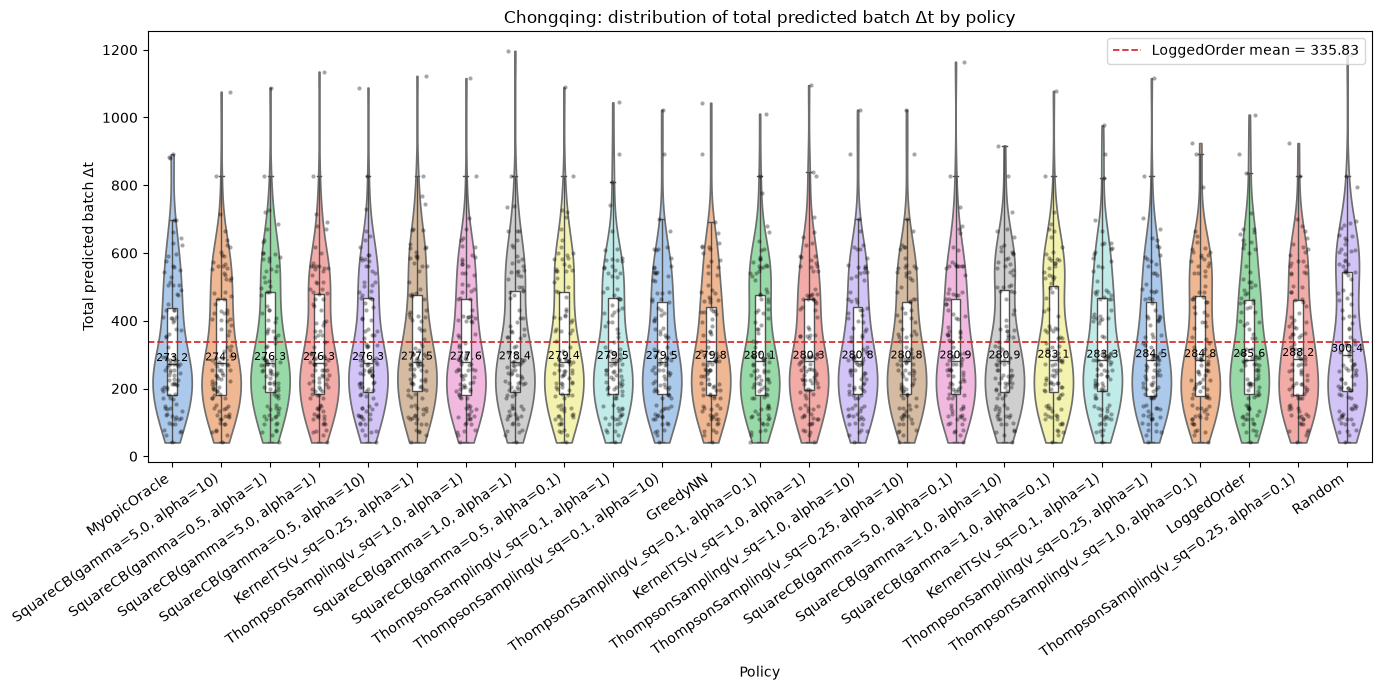

In [15]:
if __name__ == "__main__":
    # -----------------------------------------------------------------------
    # Config — adjust paths and feature lists
    # -----------------------------------------------------------------------
    from pathlib import Path

    # FINAL_FEATURES from 07_reward_oracle.py (post cyclic-encoding, no current_hour)
    # Import or redefine here.  Must match oracle training exactly.
    # Example — replace with your actual list:
    FINAL_FEATURES_EXAMPLE = (
        # structural
        ["pickup_destination_distance", "batch_size", "batch_rank_dispatch",
         "same_aoi_share_in_batch", "isolated_delivery", "distance_to_batch_centroid",
         "typecode_cb",
         # operational
         "courier_eta_ewm", "gps_points", "speed_mean_15m", "speed_std_15m",
         "distance_travelled_15m", "coverage_ratio", "gps_gap_min",
         "idle_fraction", "is_trajectory_available",
         # environment
         "WSI", "temperature_2m", "precipitation", "windspeed_10m",
         "spatial_congestion_daily", "spatial_congestion_norm",
         # temporal (raw static)
         "hour_sin", "hour_cos", "is_weekend", "is_holiday", "is_holiday_eve",
         # dynamic (recomputed each step)
         "dist_from_current", "remaining_orders", "batch_progress",
         "elapsed_route_time", "last_duration", "cumulative_distance",
         # cyclic encoding replaces current_hour
         "hour_sin_dynamic", "hour_cos_dynamic"]
    )

    if not local:
      ROOT = Path("/content/drive/MyDrive/ml/CORRECTEDv3/")
    else:
      ROOT = Path("data")

    WEIGHTS = ROOT / "LightGBMweights"

    city_configs = {
        "Shanghai": {
            "oracle_path": str(WEIGHTS / "oracle_sh.pkl"),
            "data_path": str(ROOT / "delivery_features_shanghai.parquet"),
        },
        "Hangzhou": {
            "oracle_path": str(WEIGHTS / "oracle_hz.pkl"),
            "data_path": str(ROOT / "delivery_features_hangzhou.parquet"),
        },
        "Chongqing": {
            "oracle_path": str(WEIGHTS / "oracle_cq.pkl"),
            "data_path": str(ROOT / "delivery_features_chongqing.parquet"),
        },
    }

    # Ablation A1: causal policy inputs versus the full oracle feature set.
    # Both arms use the same city oracle, batch sample, seed, and policy sweep.
    all_city_results = {}
    for city, cfg in city_configs.items():
        all_city_results[city] = run_causal_feature_ablation(
            city=city,
            oracle_model_path=cfg["oracle_path"],
            data_path=cfg["data_path"],
            oracle_feature_names=FINAL_FEATURES_EXAMPLE,
            gamma_values=[0.5, 1.0, 5.0],
            v_sq_values=[0.1, 0.25, 1.0],
            alpha_values=[0.1, 1.0, 10.0],
            max_eval_batches=100,   # set to e.g. 100 for a quick test run
        )

    # Combine across cities
    combined_metrics = pd.concat(
        [r["metrics"] for r in all_city_results.values()], ignore_index=True
    )
    print("\n\n=== A1 combined results: causal vs full policy features ===")
    print(combined_metrics.to_string(index=False))

    learned = combined_metrics[combined_metrics["policy"].str.startswith(("SquareCB", "ThompsonSampling", "KernelTS"))]
    best_by_city = (
        learned.sort_values("mean_total_batch_delta_t")
        .groupby(["city", "feature_set"], as_index=False)
        .head(1)
        [["city", "feature_set", "policy", "mean_total_batch_delta_t", "delta_t_reduction_pct_vs_logged"]]
    )
    print("\n=== Best learned configuration per city and feature set ===")
    print(best_by_city.to_string(index=False))

    # One distribution plot for the causal policy condition.
    DISTRIBUTION_PLOT_CITY = "Chongqing"
    plot_policy_duration_distributions(
        all_city_results[DISTRIBUTION_PLOT_CITY]["runs"]["causal"]["batch_results"],
        DISTRIBUTION_PLOT_CITY,
    )


### Some takeaways

- SquareCB and Thompson Sampling accumulate learning across all batches in a city — each episode updates the same policy model. This means the first 10-20 batches will perform poorly during cold start, and later batches will benefit from accumulated experience. This is a legitimate design choice (it simulates a courier who improves over a shift), but it creates a learning curve artefact in your results.The bandit is evaluated in the online learning setting where the policy improves across batches.

- With 14–16 causal features , the model needs 14–16 samples before it can make any predictions. Until then it returns 0.0 for all arms, which means the bandit selects uniformly at random. For batches with only 2–4 deliveries (which exist in the data), the policy is effectively random for the entire batch. Thus during the initial cold-start period the policy degrades to uniform exploration."

# OOD Robustness Evaluation

This additive section evaluates the existing contextual bandit policies under four held-out operating-regime shifts. The LightGBM reward oracle remains frozen, training uses only the designated batches, and test-time policy updates are disabled.

In [20]:
# OOD Robustness Evaluation
#
# Additive analysis only. The existing simulator, frozen LightGBM oracle,
# policy implementations, and IID experiment are reused unchanged.

from contextlib import contextmanager

OOD_SCENARIOS = (
    "high_workload",
    "weekday_to_weekend",
    "low_congestion_to_high_congestion",
    "good_weather_to_poor_weather",
)
OOD_FEATURE_SETS = ("causal", "full")
OOD_GAMMA_VALUES = (0.5, 1.0, 5.0)
OOD_V_SQ_VALUES = (0.1, 0.25, 1.0)
OOD_ALPHA_VALUES = (0.1, 1.0, 10.0)


def load_ood_batch_pool(data_path, oracle_feature_names, city,
                        max_eval_batches=100, random_state=42):
    """Load the IID-sized batch pool and one row of regime metadata per batch."""
    batches = load_batches_from_parquet(
        data_path, oracle_feature_names, city,
        max_batches=max_eval_batches, random_state=random_state,
    )
    selected_ids = [str(batch[0]) for batch in batches]
    if not selected_ids:
        raise ValueError(f"No batches available for {city}.")

    raw = pl.read_parquet(data_path).filter(
        pl.col("batch_id").cast(pl.Utf8).is_in(selected_ids)
    )
    exprs = []
    if "batch_size" in raw.columns:
        exprs.append(pl.col("batch_size").first().cast(pl.Float64).alias("batch_size"))
    else:
        exprs.append(pl.len().cast(pl.Float64).alias("batch_size"))

    for name in ("spatial_congestion_norm", "WSI", "precipitation", "weekday"):
        if name in raw.columns:
            exprs.append(pl.col(name).first().cast(pl.Float64).alias(name))
    for name in ("receipt_date", "receipt_time", "datetime", "ds", "sign_time"):
        if name in raw.columns:
            exprs.append(
                pl.col(name).first().cast(pl.Utf8).alias(f"date_source__{name}")
            )

    metadata = pd.DataFrame(
        raw.group_by("batch_id", maintain_order=True).agg(exprs).to_dicts()
    )
    metadata["batch_id"] = metadata["batch_id"].astype(str)
    metadata["day_of_week"] = np.nan
    date_col = next(
        (c for c in metadata.columns if c.startswith("date_source__")), None
    )
    if date_col is not None:
        metadata["day_of_week"] = pd.to_datetime(
            metadata[date_col], errors="coerce"
        ).dt.dayofweek
    if metadata["day_of_week"].isna().all() and "weekday" in metadata.columns:
        weekday = metadata["weekday"]
        numeric = pd.to_numeric(weekday, errors="coerce")
        if numeric.notna().any():
            metadata["day_of_week"] = numeric
        else:
            names = weekday.astype(str).str.lower().str[:3]
            metadata["day_of_week"] = names.map({
                "mon": 0, "tue": 1, "wed": 2, "thu": 3,
                "fri": 4, "sat": 5, "sun": 6,
            })
    return batches, metadata


def create_ood_split(batch_metadata, scenario):
    """Create disjoint training/testing batch IDs for one regime shift."""
    df = batch_metadata.copy()
    thresholds = {}
    if scenario == "high_workload":
        values = pd.to_numeric(df["batch_size"], errors="coerce")
        median, q75 = float(values.median()), float(values.quantile(.75))
        train_mask, test_mask = values <= median, values >= q75
        thresholds = {"median_batch_size": median, "q75_batch_size": q75}
    elif scenario == "weekday_to_weekend":
        values = pd.to_numeric(df["day_of_week"], errors="coerce")
        train_mask, test_mask = values <= 4, values >= 5
        thresholds = {"weekday_max": 4, "weekend_min": 5}
    elif scenario == "low_congestion_to_high_congestion":
        values = pd.to_numeric(df["spatial_congestion_norm"], errors="coerce")
        median, q75 = float(values.median()), float(values.quantile(.75))
        train_mask, test_mask = values <= median, values >= q75
        thresholds = {"median_congestion": median, "q75_congestion": q75}
    elif scenario == "good_weather_to_poor_weather":
        weather_feature = "WSI" if "WSI" in df.columns else "precipitation"
        if weather_feature not in df.columns:
            raise ValueError("Neither WSI nor precipitation is available.")
        values = pd.to_numeric(df[weather_feature], errors="coerce")
        median, q75 = float(values.median()), float(values.quantile(.75))
        train_mask, test_mask = values < median, values > q75
        thresholds = {
            "weather_feature": weather_feature,
            "median_weather": median,
            "q75_weather": q75,
        }
    else:
        raise ValueError(f"Unknown OOD scenario: {scenario}")

    valid = train_mask.notna() & test_mask.notna()
    train_ids = set(df.loc[valid & train_mask, "batch_id"].astype(str))
    test_ids = set(df.loc[valid & test_mask, "batch_id"].astype(str))
    # Ties at quantile cut-points must not leak the same batch into both sets.
    train_ids -= test_ids
    if not train_ids or not test_ids:
        raise ValueError(
            f"{scenario} produced train={len(train_ids)}, test={len(test_ids)}."
        )
    return {
        "scenario": scenario,
        "train_batch_ids": sorted(train_ids),
        "test_batch_ids": sorted(test_ids),
        "thresholds": thresholds,
    }


def _select_ood_batches(batches, batch_ids):
    wanted = set(map(str, batch_ids))
    return [batch for batch in batches if str(batch[0]) in wanted]


def collect_ood_calibration_sample(env, train_batches,
                                   max_calibration_batches=20,
                                   steps_per_batch=3, random_state=42):
    """Fit-only context calibration; no test-batch contexts or rewards are used."""
    rng = np.random.default_rng(random_state)
    contexts = []
    for batch_id, deliveries, lat, lng, hour in train_batches[:max_calibration_batches]:
        state, remaining = env.reset(deliveries, lat, lng, hour, batch_id)
        for _ in range(min(steps_per_batch, len(remaining))):
            oracle_matrix, policy_matrix = env.get_arm_vectors(remaining, state)
            contexts.append(policy_matrix)
            chosen = int(rng.integers(0, len(remaining)))
            state, _ = env.step(state, remaining[chosen], oracle_matrix[chosen])
            remaining.pop(chosen)
    if not contexts:
        raise ValueError("No training calibration contexts were collected.")
    return np.vstack(contexts)


def build_ood_policy_suite(policy_features, fit_sample, random_state=42):
    """Construct exactly the existing IID policy grid."""
    n_features = len(policy_features)
    rff_map = RandomFourierFeatureMap(
        n_features, n_components=256, random_state=random_state
    )
    rff_map.fit(fit_sample)
    policies = {
        "Random": RandomBandit(random_state),
        "GreedyNN": GreedyNNBandit(
            dist_feature_idx=policy_features.index("dist_from_current")
        ),
        "MyopicOracle": MyopicOracleBandit(),
        "LoggedOrder": LoggedOrderBandit(),
    }
    for gamma in OOD_GAMMA_VALUES:
        for alpha in OOD_ALPHA_VALUES:
            model = RidgePolicyModel(n_features, alpha=alpha)
            model.prefit_scaler(fit_sample)
            bandit = SquareCBBandit(model, gamma=gamma, random_state=random_state)
            policies[bandit.name] = bandit
    for v_sq in OOD_V_SQ_VALUES:
        for alpha in OOD_ALPHA_VALUES:
            model = RidgePolicyModel(n_features, alpha=alpha)
            model.prefit_scaler(fit_sample)
            bandit = ThompsonSamplingBandit(
                n_features, v_sq=v_sq, alpha=alpha,
                random_state=random_state, policy_model=model,
            )
            policies[bandit.name] = bandit
    for v_sq in OOD_V_SQ_VALUES:
        model = RFFPolicyModel(rff_map, alpha=1.0)
        model.prefit_scaler(fit_sample)
        bandit = ThompsonSamplingBandit(
            n_features, v_sq=v_sq, random_state=random_state,
            policy_model=model,
        )
        policies[bandit.name] = bandit
    return policies


def train_policy(sim, policy, train_batches, city):
    """Train a single policy only on its split's training batches."""
    for batch_id, deliveries, lat, lng, hour in train_batches:
        sim.run_episode(list(deliveries), policy, city, lat, lng, hour, batch_id)


@contextmanager
def freeze_policy_updates(policy):
    """Freeze only this policy instance during held-out evaluation."""
    original_update = policy.update
    policy.update = lambda *args, **kwargs: None
    try:
        yield
    finally:
        policy.update = original_update


def evaluate_policy(sim, policy, test_batches, city):
    """Evaluate without updating; simulator type checks remain intact."""
    results = []
    with freeze_policy_updates(policy):
        for batch_id, deliveries, lat, lng, hour in test_batches:
            results.append(
                sim.run_episode(list(deliveries), policy, city, lat, lng, hour, batch_id)
            )
    return results


def compute_ood_paired_statistics(test_frame):
    logged = test_frame[test_frame["policy"] == "LoggedOrder"][
        ["batch_id", "total_duration"]
    ].rename(columns={"total_duration": "logged_total_duration"})
    rows = []
    for policy in test_frame["policy"].drop_duplicates():
        current = test_frame[test_frame["policy"] == policy][
            ["batch_id", "total_duration"]
        ].rename(columns={"total_duration": "current_total_duration"})
        paired = current.merge(logged, on="batch_id", how="inner")
        differences = paired["current_total_duration"] - paired["logged_total_duration"]
        if len(differences) < 2 or differences.std(ddof=1) == 0:
            p_value = np.nan
        else:
            p_value = float(stats.ttest_rel(
                paired["current_total_duration"], paired["logged_total_duration"]
            ).pvalue)
        rows.append({
            "policy": policy,
            "mean_paired_delta_vs_logged": float(differences.mean()),
            "paired_t_p_value": p_value,
            "paired_t_sig_005": bool(not np.isnan(p_value) and p_value < 0.05),
            "n_paired": len(paired),
        })
    return pd.DataFrame(rows)


def build_ood_summary(test_metrics):
    """Summarize OOD test results: reduction % vs each baseline policy."""
    rows = []
    logged_dur = test_metrics[test_metrics["policy"] == "LoggedOrder"]["total_duration"].mean()
    random_dur = test_metrics[test_metrics["policy"] == "Random"]["total_duration"].mean()
    oracle_dur = test_metrics[test_metrics["policy"] == "MyopicOracle"]["total_duration"].mean()
    for policy in test_metrics["policy"].unique():
        if policy in ("LoggedOrder", "MyopicOracle", "Random"):
            continue
        mean_dur = test_metrics[test_metrics["policy"] == policy]["total_duration"].mean()
        npg = (
            (mean_dur - oracle_dur) / (random_dur - oracle_dur)
            if random_dur != oracle_dur else np.nan
        )
        rows.append({
            "policy": policy,
            "mean_total_duration": round(mean_dur, 3),
            "reduction_pct_vs_logged": round((logged_dur - mean_dur) / logged_dur * 100, 2),
            "reduction_pct_vs_random": round((random_dur - mean_dur) / random_dur * 100, 2),
            "NPG": round(npg, 4) if not np.isnan(npg) else np.nan,
        })
    return pd.DataFrame(rows)


def run_ood_experiment(scenario, city, oracle_model_path, data_path,
                       oracle_feature_names, feature_set, iid_metrics,
                       max_eval_batches=100, random_state=42):
    """Train on one regime and evaluate frozen policies on the other regime."""
    batches, metadata = load_ood_batch_pool(
        data_path, oracle_feature_names, city,
        max_eval_batches=max_eval_batches, random_state=random_state,
    )
    split = create_ood_split(metadata, scenario)
    train_batches = _select_ood_batches(batches, split["train_batch_ids"])
    test_batches = _select_ood_batches(batches, split["test_batch_ids"])

    oracle = LightGBMOracle(oracle_model_path, oracle_feature_names)
    policy_features = (
        get_causal_features(city) if feature_set == "causal"
        else oracle_feature_names
    )

    # Collect calibration contexts from training batches
    env = BatchEnvironment(oracle, oracle_feature_names, policy_features)
    fit_sample = collect_ood_calibration_sample(
        env, train_batches, max_calibration_batches=20, steps_per_batch=3,
        random_state=random_state,
    )

    # Build and train policy suite
    policies = build_ood_policy_suite(policy_features, fit_sample, random_state=random_state)
    sim = Simulator(env)
    for policy in policies.values():
        train_policy(sim, policy, train_batches, city)

    # Evaluate all policies on test batches (frozen updates)
    test_results = {}
    for policy_name, policy in policies.items():
        test_results[policy_name] = evaluate_policy(sim, policy, test_batches, city)

    # Baselines: MyopicOracle and LoggedOrder (always evaluated frozen)
    oracle_results = evaluate_policy(sim, MyopicOracleBandit(), test_batches, city)
    test_results["MyopicOracle"] = oracle_results
    logged_results = evaluate_policy(sim, LoggedOrderBandit(), test_batches, city)
    test_results["LoggedOrder"] = logged_results

    # Aggregate results
    test_frame = pd.DataFrame([
        {"policy": name, "batch_id": r.batch_id, "total_duration": r.total_duration}
        for name, results in test_results.items() for r in results
    ])

    paired_stats = compute_ood_paired_statistics(test_frame)
    test_metrics = test_frame.groupby("policy").agg(
        total_duration=("total_duration", "mean"),
        std_duration=("total_duration", "std"),
        n_batches=("batch_id", "nunique"),
    ).reset_index()
    test_metrics = test_metrics.merge(paired_stats, on="policy", how="left")

    return {
        "scenario": scenario,
        "city": city,
        "feature_set": feature_set,
        "train_regime": split["thresholds"],
        "n_train_batches": len(train_batches),
        "n_test_batches": len(test_batches),
        "iid_metrics": iid_metrics,
        "test_metrics": test_metrics,
        "summary": build_ood_summary(test_metrics),
    }


def run_all_ood_experiments(city_configs, oracle_feature_names, iid_results,
                            max_eval_batches=100, random_state=42):
    """Run all combinations of scenario × city × feature_set."""
    OOD_RESULTS = {}
    for scenario in OOD_SCENARIOS:
        for city, config in city_configs.items():
            for feature_set in OOD_FEATURE_SETS:
                print(f"Running OOD={scenario}, city={city}, features={feature_set}")
                result = run_ood_experiment(
                    scenario, city, config["oracle_path"], config["data_path"],
                    oracle_feature_names, feature_set,
                    iid_results[city]["runs"][feature_set]["metrics"],
                    max_eval_batches=max_eval_batches, random_state=random_state,
                )
                key = (scenario, city, feature_set)
                OOD_RESULTS[key] = result
    return OOD_RESULTS


OOD_RESULTS = run_all_ood_experiments(
    city_configs, FINAL_FEATURES_EXAMPLE, all_city_results,
    max_eval_batches=100, random_state=42,
)

Running OOD=high_workload, city=Shanghai, features=causal


C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):


Running OOD=high_workload, city=Shanghai, features=full


C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):


Running OOD=high_workload, city=Hangzhou, features=causal


...

C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):


Running OOD=good_weather_to_poor_weather, city=Chongqing, features=causal


C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):


Running OOD=good_weather_to_poor_weather, city=Chongqing, features=full


C:\Users\aymuo\AppData\Local\Temp\ipykernel_4712\1687756600.py:34: DeprecationWarning: `group_by` iteration will change to always return group identifiers as tuples. Pass `by` as a list to silence this warning, e.g. `group_by(['batch_id'])`.
  for batch_id, group in df.sort("batch_id").group_by("batch_id", maintain_order=True):


In [22]:

# Display OOD Results Summary
print("=" * 100)
print("OOD ROBUSTNESS EVALUATION RESULTS")
print("=" * 100)

for (scenario, city, feature_set), result in sorted(OOD_RESULTS.items()):
    print(f"\n{'='*100}")
    print(f"Scenario: {scenario.upper()} | City: {city} | Feature Set: {feature_set}")
    print(f"{'='*100}")
    print(f"Train Regime Thresholds: {result['train_regime']}")
    print(f"Train Batches: {result['n_train_batches']} | Test Batches: {result['n_test_batches']}")
    print(f"\nTest Metrics Summary:")
    print(result['test_metrics'].to_string(index=False))
    print(f"\nPolicy Performance Summary (vs baselines):")
    print(result['summary'].to_string(index=False))

print("\n" + "=" * 100)
print("AGGREGATED RESULTS BY SCENARIO")
print("=" * 100)

# Aggregate results across cities and feature sets for each scenario
for scenario in OOD_SCENARIOS:
    print(f"\n{scenario.upper()}:")
    print("-" * 100)
    for city in city_configs.keys():
        for fs in OOD_FEATURE_SETS:
            if (scenario, city, fs) in OOD_RESULTS:
                summary_df = OOD_RESULTS[(scenario, city, fs)]['summary']
                print(f"\n  {city} ({fs}):")
                print(summary_df.to_string(index=False).replace('\n', '\n    '))

OOD ROBUSTNESS EVALUATION RESULTS

Scenario: GOOD_WEATHER_TO_POOR_WEATHER | City: Chongqing | Feature Set: causal
Train Regime Thresholds: {'weather_feature': 'WSI', 'median_weather': 0.2392, 'q75_weather': 0.35277499999999995}
Train Batches: 50 | Test Batches: 25

Test Metrics Summary:
                                policy  total_duration  std_duration  n_batches  mean_paired_delta_vs_logged  paired_t_p_value  paired_t_sig_005  n_paired
                              GreedyNN      305.626248    127.104020         25                   -12.388074          0.135419             False        25
           KernelTS(v_sq=0.1, alpha=1)      319.239451    136.230882         25                     1.225129          0.875561             False        25
          KernelTS(v_sq=0.25, alpha=1)      314.341686    128.984697         25                    -3.672636          0.691848             False        25
           KernelTS(v_sq=1.0, alpha=1)      322.220737    135.987883         25             

In [23]:

# Create a summary table of key results
print("\n" + "=" * 100)
print("SUMMARY: Mean NPG and Reduction % vs Logged Order (across all policies)")
print("=" * 100)

summary_rows = []
for (scenario, city, feature_set), result in sorted(OOD_RESULTS.items()):
    summary_df = result['summary']
    if len(summary_df) > 0:
        # Get mean NPG and mean reduction across all learned policies
        mean_npg = summary_df['NPG'].mean()
        mean_reduction = summary_df['reduction_pct_vs_logged'].mean()
        best_policy = summary_df.loc[summary_df['reduction_pct_vs_logged'].idxmax(), 'policy']
        best_reduction = summary_df['reduction_pct_vs_logged'].max()
        
        summary_rows.append({
            'Scenario': scenario,
            'City': city,
            'Feature Set': feature_set,
            'Mean NPG': round(mean_npg, 4),
            'Best Policy': best_policy,
            'Best Reduction %': round(best_reduction, 2),
            'N Policies': len(summary_df)
        })

summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))

print("\n" + "=" * 100)
print("KEY FINDINGS BY SCENARIO")
print("=" * 100)

for scenario in OOD_SCENARIOS:
    scenario_data = summary_table[summary_table['Scenario'] == scenario]
    if len(scenario_data) > 0:
        print(f"\n{scenario.upper()}:")
        print(f"  - Number of experiments: {len(scenario_data)}")
        print(f"  - Mean NPG across all: {scenario_data['Mean NPG'].mean():.4f}")
        print(f"  - Best reduction % achieved: {scenario_data['Best Reduction %'].max():.2f}%")
        print(f"  - Causal vs Full features comparison:")
        causal_data = scenario_data[scenario_data['Feature Set'] == 'causal']
        full_data = scenario_data[scenario_data['Feature Set'] == 'full']
        if len(causal_data) > 0:
            print(f"    - Causal (mean NPG): {causal_data['Mean NPG'].mean():.4f}")
        if len(full_data) > 0:
            print(f"    - Full   (mean NPG): {full_data['Mean NPG'].mean():.4f}")


SUMMARY: Mean NPG and Reduction % vs Logged Order (across all policies)
                         Scenario      City Feature Set  Mean NPG                            Best Policy  Best Reduction %  N Policies
     good_weather_to_poor_weather Chongqing      causal    0.5172                               GreedyNN              3.90          22
     good_weather_to_poor_weather Chongqing        full    0.4053                               GreedyNN              3.90          22
     good_weather_to_poor_weather  Hangzhou      causal    0.4340                               GreedyNN              5.42          22
     good_weather_to_poor_weather  Hangzhou        full    0.4713                               GreedyNN              5.42          22
     good_weather_to_poor_weather  Shanghai      causal    0.5254                               GreedyNN             12.56          22
     good_weather_to_poor_weather  Shanghai        full    0.3480                               GreedyNN             